<h1 style="text-align: center;">Demo: Model Understanding</h1>

The data set for the demo is an **Student Performance Data Set** where the task is to predict student performance in secondary education (high school).

The data comes from [the UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/datasets/student+performance)





## Install the required packages

In [ ]:
if get_ipython().__class__.__module__ == "google.colab._shell":
  !pip install -q "cython<3"
  !pip install -q git+https://github.com/gavin-s-smith/mcrforest
  !pip install -q git+https://github.com/SauceCat/PDPbox.git
  !pip install -q boruta
  !pip install -q category_encoders
  !pip -q install shap

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done


## Some helper code for plotting side-by-side bar charts

In [ ]:
!pip install -q category_encoders

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
#from pdpbox import pdp, get_dataset, info_plots
from sklearn.inspection import PartialDependenceDisplay
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsRegressor

def plot_sidebyside_bar( labels, series1, series2, xlabel_in = '', figwidth = 20 ):
  # The data
  indices = range(len(series1))
  names = labels
  # Calculate optimal width
  width = np.min(np.diff(indices))/3.

  fig = plt.figure()
  ax = fig.add_subplot(111)
  ax.bar(indices-width/2.,series1,width,color='b',label='-Ymin')
  ax.bar(indices+width/2.,series2,width,color='r',label='Ymax')
  #tiks = ax.get_xticks().tolist()
  plt.xticks(indices)
  ax.axes.set_xticklabels(names, rotation='vertical')
  ax.set_xlabel(xlabel_in)
  plt.gcf().set_figwidth(figwidth)
  plt.show()

## Load the data

In [ ]:
from pandas import read_csv

data = read_csv('https://drive.google.com/uc?export=download&id=1eIFbuMQ3_9t1pliP0UkGH-gg7PeHUUkr', delimiter = ';')

# Fix the column headings
new_header = []
for x in data.columns:
  new_header.append( x.strip() )

data.columns = new_header

## Look at the data and setup the required pre-processing

In [ ]:
from category_encoders.one_hot import OneHotEncoder
ohe = OneHotEncoder(use_cat_names = True, handle_unknown='ignore')
ohe.fit(data)

datao = ohe.transform(data)
datao = datao.drop(columns = ['G1','G2'])

## Now let's consider basic summaries of high and low performing students

In [ ]:
data_low = datao[datao.G3 <=10]
data_high = datao[datao.G3 >10]

In [ ]:
data_low.describe()

,school_GP,school_MS,sex_F,sex_M,age,address_U,address_R,famsize_GT3,famsize_LE3,Pstatus_A,...,romantic_no,romantic_yes,famrel,freetime,goout,Dalc,Walc,health,absences,G3
count,186.000000,186.000000,186.000000,186.000000,186.000000,186.000000,186.000000,186.000000,186.000000,186.000000,...,186.000000,186.000000,186.000000,186.000000,186.000000,186.000000,186.000000,186.000000,186.000000,186.000000
mean,0.854839,0.145161,0.564516,0.435484,16.903226,0.731183,0.268817,0.731183,0.268817,0.086022,...,0.661290,0.338710,3.956989,3.236559,3.290323,1.548387,2.467742,3.569892,6.188172,6.774194
std,0.353214,0.353214,0.497158,0.497158,1.311607,0.444541,0.444541,0.444541,0.444541,0.281153,...,0.474548,0.474548,0.824149,0.979772,1.144488,0.882455,1.340243,1.318458,9.139878,3.714483
min,0.000000,0.000000,0.000000,0.000000,15.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000,0.000000,16.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,6.000000
50%,1.000000,0.000000,1.000000,0.000000,17.000000,1.000000,0.000000,1.000000,0.000000,0.000000,...,1.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,8.000000
75%,1.000000,0.000000,1.000000,1.000000,18.000000,1.000000,1.000000,1.000000,1.000000,0.000000,...,1.000000,1.000000,4.000000,4.000000,4.000000,2.000000,3.750000,5.000000,8.000000,10.000000
max,1.000000,1.000000,1.000000,1.000000,22.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,10.000000


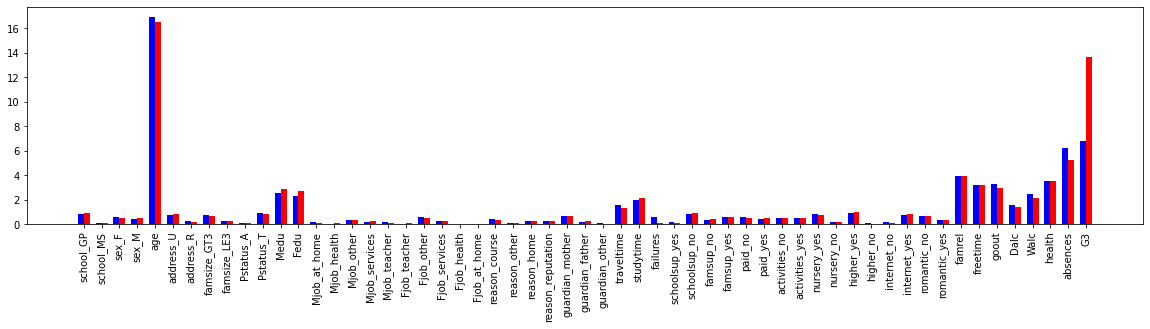

In [ ]:
plot_sidebyside_bar( data_low.mean().index,data_low.mean().tolist(), data_high.mean().tolist() )

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
X = datao.drop(columns=['G3'])
y = datao.G3
ss = StandardScaler()
ss.fit(X)



dl = pd.DataFrame( ss.transform(data_low.drop(columns = ['G3'])), columns = data_low.drop(columns = ['G3']).columns)

dh = pd.DataFrame( ss.transform(data_high.drop(columns = ['G3'])), columns = data_high.drop(columns = ['G3']).columns)


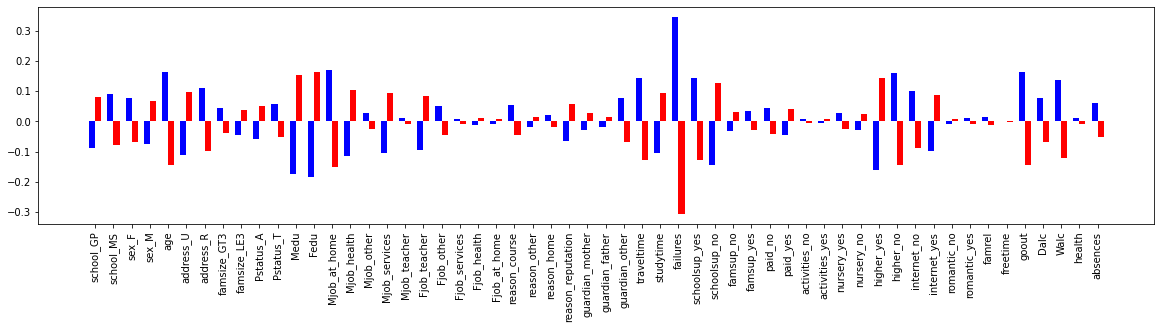

In [ ]:

plot_sidebyside_bar( dl.mean().index,dl.mean().tolist(), dh.mean().tolist() )

## Let's try using Variable Importance to achive the same thing

In [ ]:
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestRegressor


rf_perm_model = RandomForestRegressor(n_estimators = 100, max_depth=10) # Note, we really should have learnt the meta-parameters correctly as per the sessions on evaluation
rf_perm_model.fit(X,y)

feature_importances = permutation_importance(rf_perm_model, X, y)  # here I am using the training set....

In [ ]:
feature_importances

{'importances_mean': array([0.00258757, 0.00511039, 0.03453134, 0.02673163, 0.05602907,
        0.00490137, 0.00495147, 0.00741767, 0.00622743, 0.00357313,
        0.00316998, 0.07767087, 0.02514706, 0.03491483, 0.00690311,
        0.011737  , 0.0253591 , 0.0073279 , 0.01777301, 0.01078921,
        0.00449722, 0.00079018, 0.0105977 , 0.01768093, 0.0043198 ,
        0.00517009, 0.01567621, 0.00477628, 0.00535058, 0.01908197,
        0.02764092, 0.03450793, 0.44766821, 0.02884401, 0.01753411,
        0.00641248, 0.00766496, 0.00446871, 0.00418373, 0.00805794,
        0.00344908, 0.00382239, 0.00335213, 0.00658844, 0.0096399 ,
        0.0036215 , 0.00552459, 0.01780108, 0.00976699, 0.02436024,
        0.03878323, 0.08952186, 0.01617832, 0.03883842, 0.05325518,
        0.42444293]),
 'importances_std': array([0.00048493, 0.00088005, 0.00312288, 0.0017701 , 0.00248128,
        0.00032954, 0.00052111, 0.00072688, 0.0005269 , 0.00070466,
        0.00030954, 0.00668457, 0.00348504, 0.00681436,

<ipython-input-30-c0afd1350708>:5: UserWarning: FixedFormatter should only be used together with FixedLocator
  plt.gca().axes.set_xticklabels(X.columns,rotation='vertical')


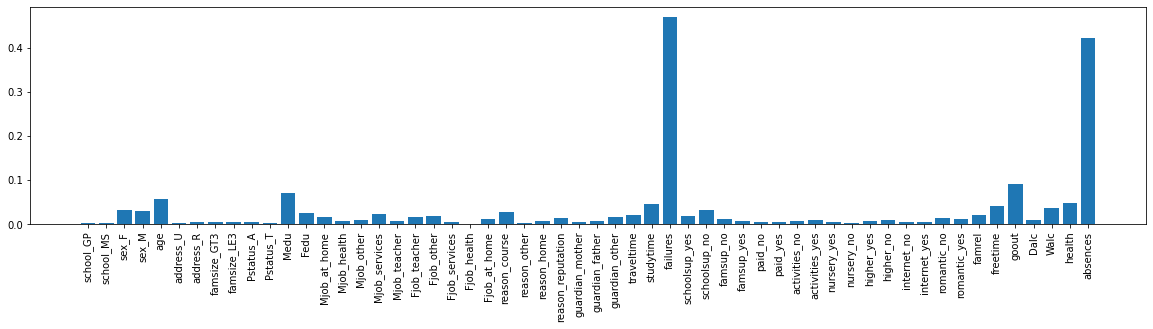

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
plt.bar(X.columns, feature_importances.importances_mean)
plt.gcf().set_figwidth(20)
plt.gca().axes.set_xticklabels(X.columns,rotation='vertical')
plt.show()

## But wait, we probably should verify that a Random Forest is a good model...

In [ ]:
model = KNeighborsRegressor(n_neighbors=10)
scores = cross_val_score(model, X, y, cv=5, scoring = 'neg_mean_absolute_error' )
print(np.mean(np.abs(scores)))

3.2827848101265813


In [ ]:
model = RandomForestRegressor(n_estimators = 500, max_depth = 10, oob_score=True)
scores = cross_val_score(model, X, y, cv=5, scoring = 'neg_mean_absolute_error' )
print(np.mean(np.abs(scores)))

3.146592841960982


In [ ]:
print('MAE as a fraction of the average score: {}'.format(np.mean(np.abs(scores))/np.mean(y)))

MAE as a fraction of the average score: 0.3041718586985854


## Instead of manually searching for informative features we could have used Boruta

In [ ]:
!pip install boruta

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
ERROR: Operation cancelled by user
Traceback (most recent call last):
  File "/usr/local/lib/python3.9/dist-packages/pip/_vendor/pkg_resources/__init__.py", line 3021, in _dep_map
    return self.__dep_map
  File "/usr/local/lib/python3.9/dist-packages/pip/_vendor/pkg_resources/__init__.py", line 2815, in __getattr__
    raise AttributeError(attr)
AttributeError: _DistInfoDistribution__dep_map

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/local/lib/python3.9/dist-packages/pip/_vendor/pyparsing/results.py", line 184, in __init__
    self[name] = toklist[0]
TypeError: 'int' object is not subscriptable

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/local/lib/python3.9/dist-packages/pip/_internal/cli/base_command.py", line 167, in exc_logging_wrapper
 

In [ ]:
from boruta import BorutaPy
rf = RandomForestRegressor(n_estimators = 100, max_depth = 10)

X = datao.drop(columns=['G3'])
y = datao.G3

rf.fit(X,y)

feat_selector = BorutaPy(rf, n_estimators='auto', verbose=2, random_state=1)
feat_selector.fit(X.values, y)

Iteration: 	1 / 100
Confirmed: 	0
Tentative: 	56
Rejected: 	0
Iteration: 	2 / 100
Confirmed: 	0
Tentative: 	56
Rejected: 	0
Iteration: 	3 / 100
Confirmed: 	0
Tentative: 	56
Rejected: 	0
Iteration: 	4 / 100
Confirmed: 	0
Tentative: 	56
Rejected: 	0
Iteration: 	5 / 100
Confirmed: 	0
Tentative: 	56
Rejected: 	0
Iteration: 	6 / 100
Confirmed: 	0
Tentative: 	56
Rejected: 	0
Iteration: 	7 / 100
Confirmed: 	0
Tentative: 	56
Rejected: 	0
Iteration: 	8 / 100
Confirmed: 	0
Tentative: 	3
Rejected: 	53
Iteration: 	9 / 100
Confirmed: 	2
Tentative: 	1
Rejected: 	53
Iteration: 	10 / 100
Confirmed: 	2
Tentative: 	1
Rejected: 	53
Iteration: 	11 / 100
Confirmed: 	2
Tentative: 	1
Rejected: 	53
Iteration: 	12 / 100
Confirmed: 	2
Tentative: 	0
Rejected: 	54


BorutaPy finished running.

Iteration: 	13 / 100
Confirmed: 	2
Tentative: 	0
Rejected: 	54


BorutaPy(estimator=RandomForestRegressor(max_depth=10, n_estimators=24,
                                         random_state=RandomState(MT19937) at 0x7FEFBEDBCE40),
         n_estimators='auto',
         random_state=RandomState(MT19937) at 0x7FEFBEDBCE40, verbose=2)

In [ ]:
print( X.columns[feat_selector.support_] )

Index(['failures', 'absences'], dtype='object')


In [ ]:
# What does MCR say?
from mcrforest.forest import RandomForestRegressor as RandomForestRegressorMCR
rfd = RandomForestRegressorMCR(n_estimators = 100, max_depth = 10)
#results2 = rfd.plot_mcr(X,y.values.flatten(), num_times = 50, include_permutation_importance = True)

ImportError: ignored

## Now we're happy that the two features are enough, let's consider how they affect our output feature

In [ ]:
from pdpbox import pdp, get_dataset, info_plots

In [ ]:
model.fit(X,y)

RandomForestRegressor(bootstrap=True, criterion='mse', max_depth=None,
           max_features='auto', max_leaf_nodes=None,
           min_impurity_decrease=0.0, min_impurity_split=None,
           min_samples_leaf=1, min_samples_split=10,
           min_weight_fraction_leaf=0.0, n_estimators=100, n_jobs=None,
           oob_score=True, random_state=None, verbose=0, warm_start=False)

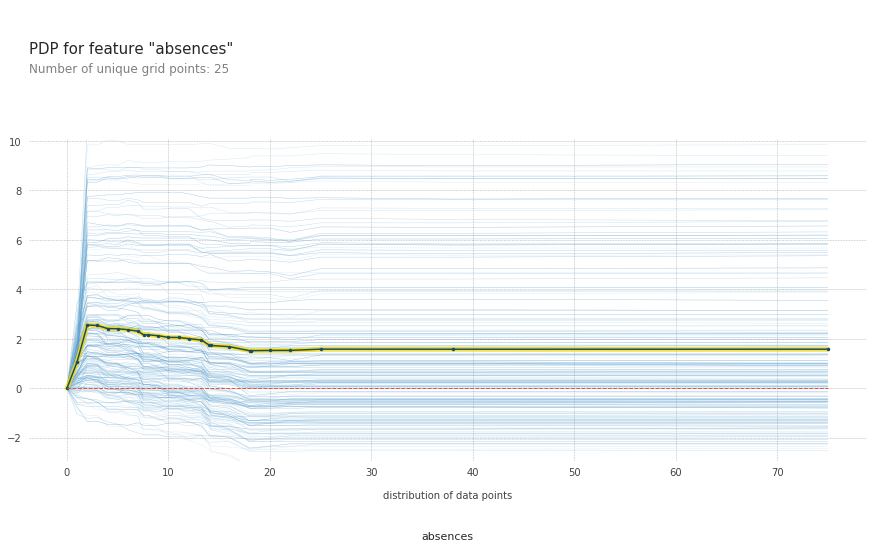

In [ ]:
pdp_obj = pdp.pdp_isolate(
    model=model, dataset=X, model_features=X.columns, feature='absences',num_grid_points = 100
)

fig, axes = pdp.pdp_plot(pdp_obj, 'absences', plot_lines=True, frac_to_plot=0.5, plot_pts_dist=True)

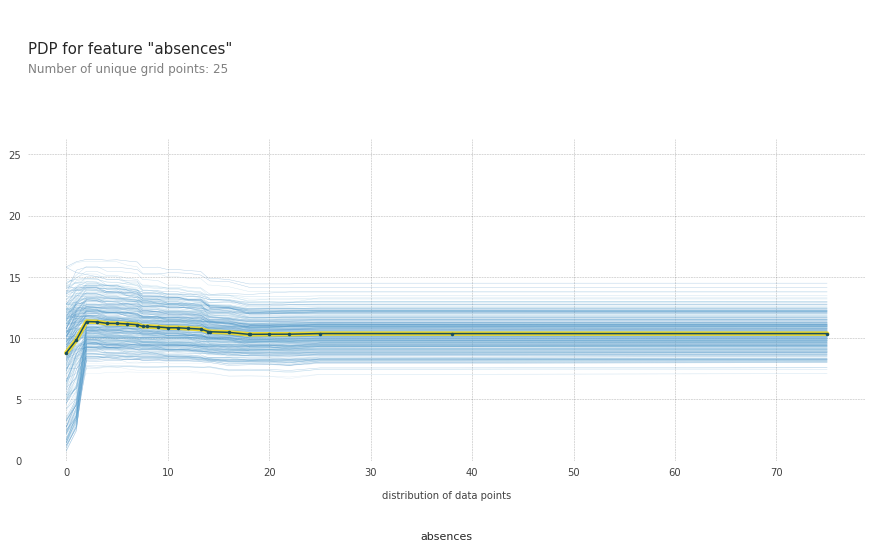

In [ ]:
# We do not have to center the curves (i.e. start them at zero).
# Sometimes this can give us a more interpretable result
fig, axes = pdp.pdp_plot(pdp_obj, 'absences', plot_lines=True, frac_to_plot=0.9, plot_pts_dist=True, center = False)

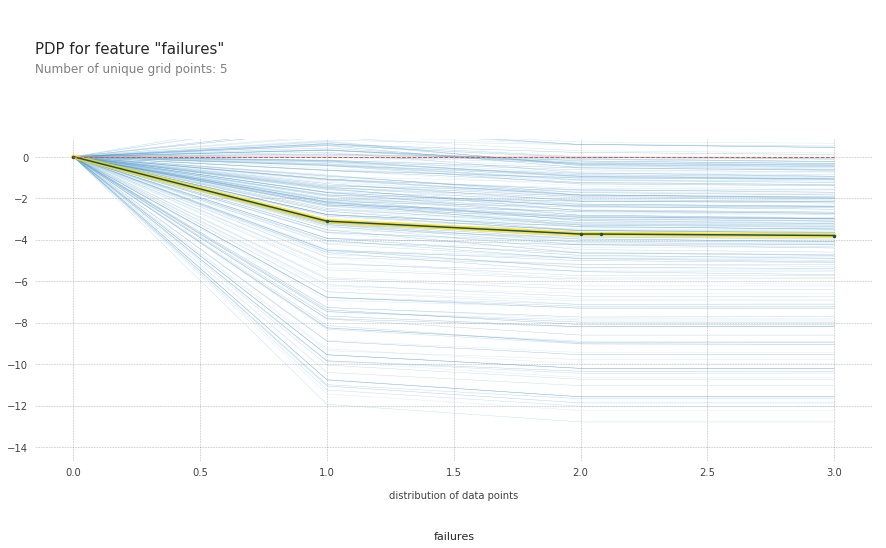

In [ ]:
pdp_obj = pdp.pdp_isolate(
    model=model, dataset=datao, model_features=X.columns, feature='failures',num_grid_points = 100
)

fig, axes = pdp.pdp_plot(pdp_obj, 'failures', plot_lines=True, frac_to_plot=0.5, plot_pts_dist=True)

(<Figure size 1800x720 with 3 Axes>,
 {'pdp_inter_ax': <matplotlib.axes._subplots.AxesSubplot at 0x7fb0541d1128>,
  'title_ax': <matplotlib.axes._subplots.AxesSubplot at 0x7fb0542304a8>})

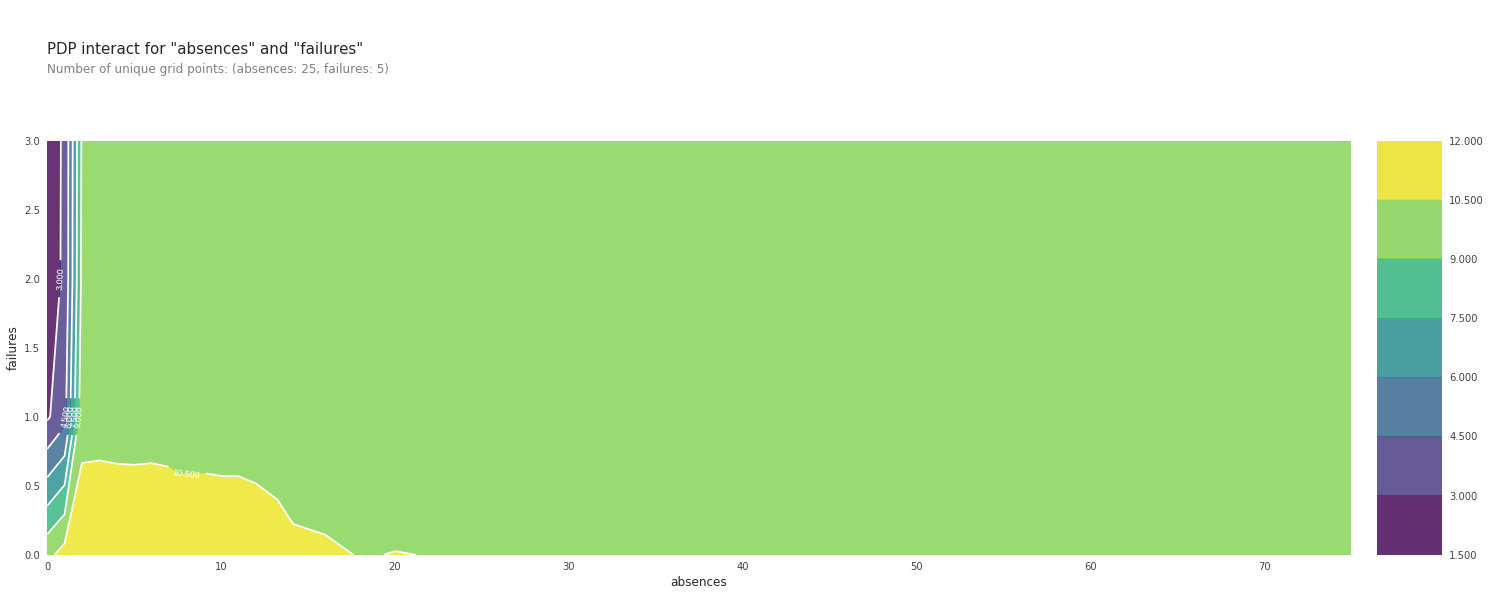

In [ ]:
feats = ['absences', 'failures']
p = pdp.pdp_interact(model, X, X.columns, feats,num_grid_points = [100,100])
pdp.pdp_interact_plot(p, feats, figsize = (25,10))

# What about if we only had a model with two features?

In [ ]:
Xaf = X[['absences', 'failures']]

In [ ]:

model = RandomForestRegressor(n_estimators = 100, min_samples_split = 10, oob_score=True)

scores = cross_val_score(model, Xaf, y, cv=5, scoring = 'neg_mean_absolute_error' )

print('scores: {}'.format( np.mean(np.abs(scores))) )

scores: 3.247654987735104


In [ ]:
model.fit(Xaf,y)

RandomForestRegressor(bootstrap=True, criterion='mse', max_depth=None,
           max_features='auto', max_leaf_nodes=None,
           min_impurity_decrease=0.0, min_impurity_split=None,
           min_samples_leaf=1, min_samples_split=10,
           min_weight_fraction_leaf=0.0, n_estimators=100, n_jobs=None,
           oob_score=True, random_state=None, verbose=0, warm_start=False)

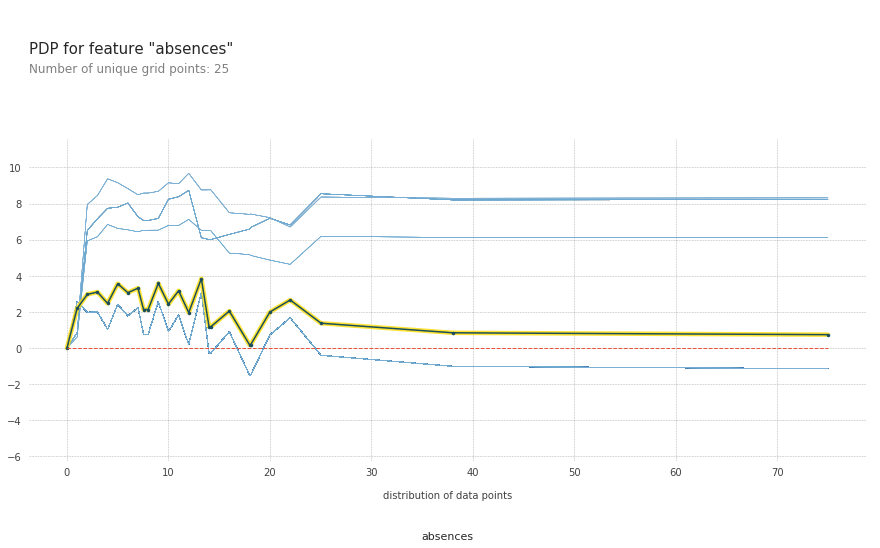

In [ ]:
pdp_obj = pdp.pdp_isolate(
    model=model, dataset=Xaf, model_features=Xaf.columns, feature='absences', num_grid_points=100
)

fig, axes = pdp.pdp_plot(pdp_obj, 'absences', plot_lines=True, frac_to_plot=0.9, plot_pts_dist=True, center = True)

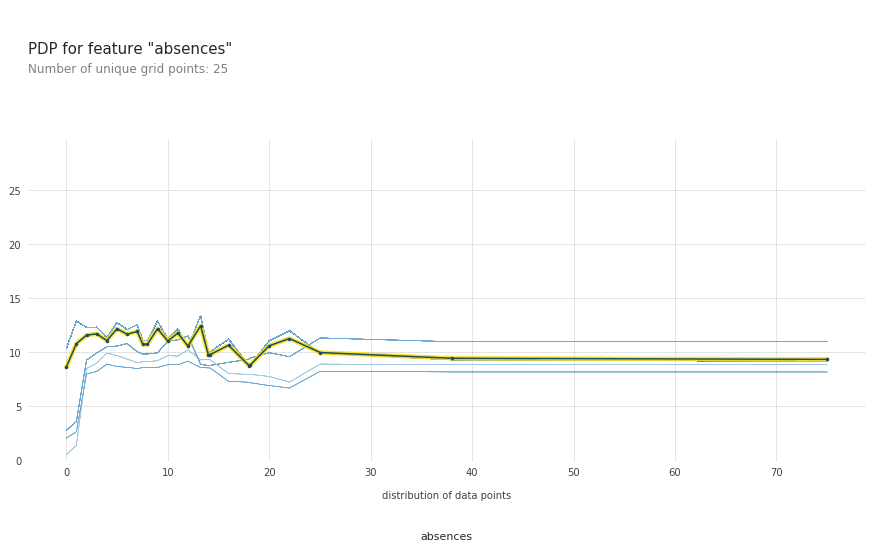

In [ ]:
# We do not have to center the curves (i.e. start them at zero).
# Sometimes this can give us a more interpretable result
fig, axes = pdp.pdp_plot(pdp_obj, 'absences', plot_lines=True, frac_to_plot=0.9, plot_pts_dist=True, center = False)

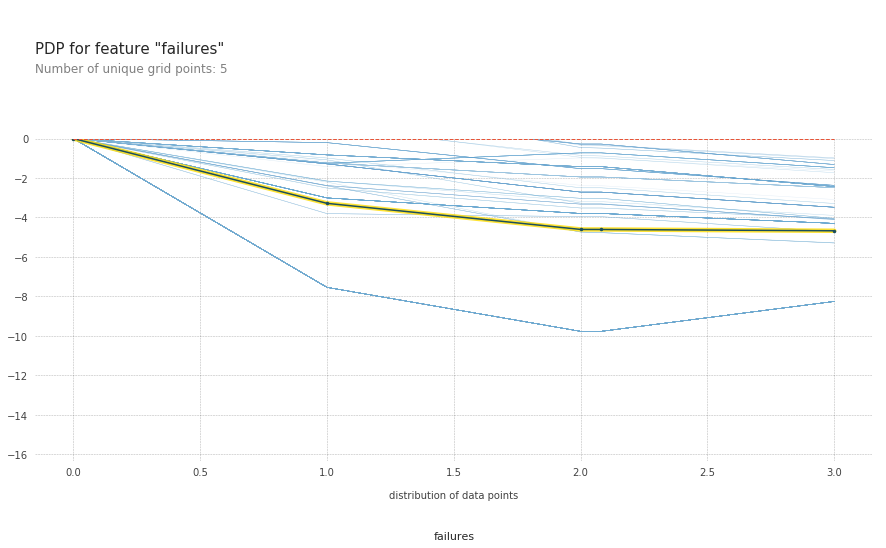

In [ ]:
pdp_obj = pdp.pdp_isolate(
    model=model, dataset=Xaf, model_features=Xaf.columns, feature='failures',  num_grid_points=100,
)

fig, axes = pdp.pdp_plot(pdp_obj, 'failures', plot_lines=True, frac_to_plot=0.5, plot_pts_dist=True,center = True)

(<Figure size 1800x720 with 3 Axes>,
 {'pdp_inter_ax': <matplotlib.axes._subplots.AxesSubplot at 0x7fb06e042710>,
  'title_ax': <matplotlib.axes._subplots.AxesSubplot at 0x7fb053c7f2b0>})

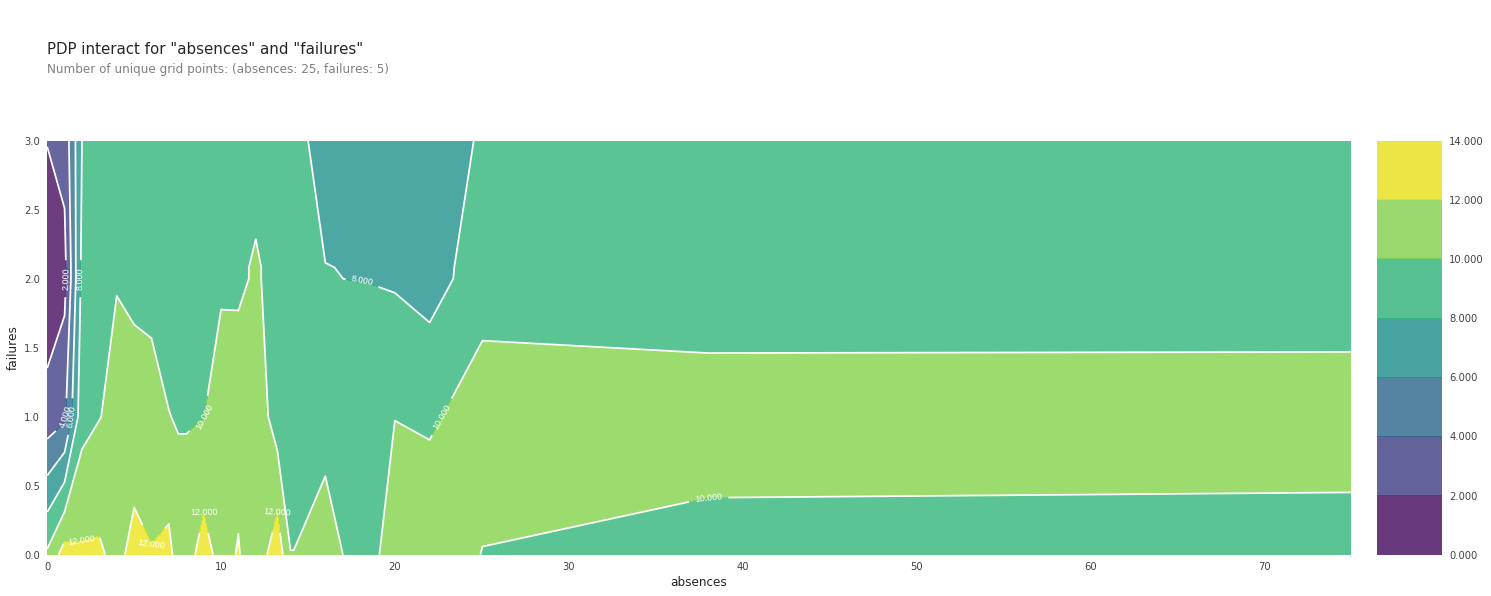

In [ ]:
feats = ['absences', 'failures']
p = pdp.pdp_interact(model, Xaf, Xaf.columns, feats, num_grid_points = [100,100])
pdp.pdp_interact_plot(p, feats, figsize = (25,10))

Some issues here: Seems like there is not enough data / the model is poorly defined.

What can we take away?

Why might the score not change much as the number of failures and absences go up? Is this an artifact of the model or the data?

One explaination might be that we get very few data points at that end. Our model is fit to those that exist, and those that "survive" are the students who don't drop out. I.e. those that, despite high absences and failures persist and end up doing ok.

## What about SHAP?

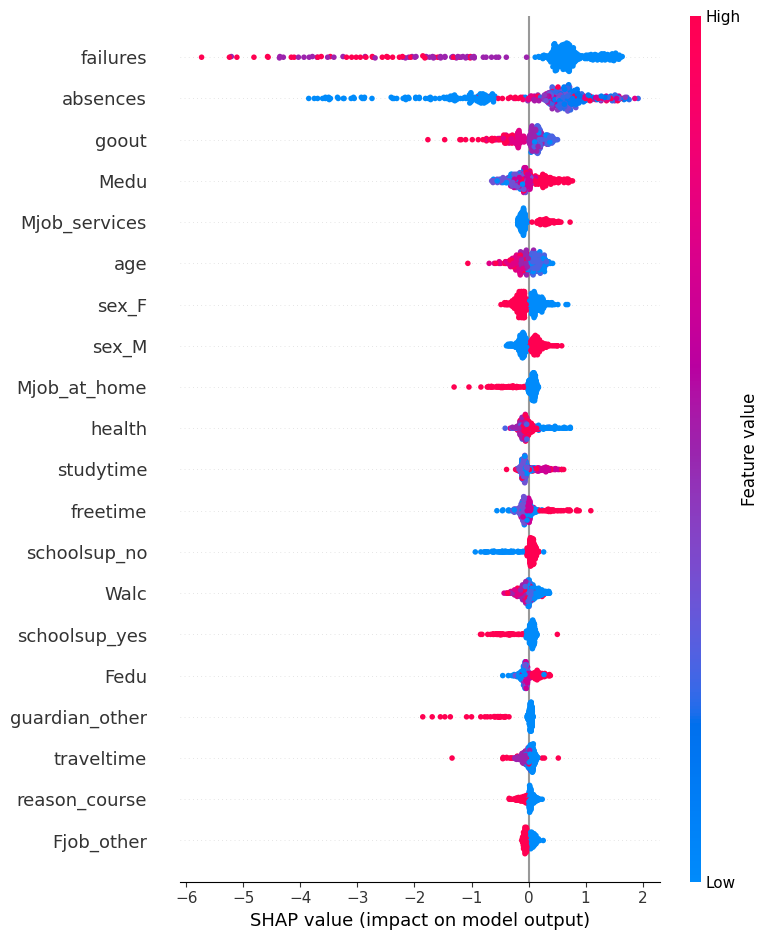

In [ ]:
import shap
model = RandomForestRegressor(n_estimators = 100, min_samples_split = 10, oob_score=True)
model.fit(X,y)
shap_values = shap.TreeExplainer(model).shap_values(X)
shap.summary_plot(shap_values, X)